# 04 Model Training & Ranking

This notebook implements the unsupervised baseline model for **Problem 6: The Overpayment Signal**.

### Objectives:
1. Inspect the engineered features and select appropriate non-demographic inputs for the model.
2. Train an unsupervised `IsolationForest` model to detect anomalous patterns.
3. Generate an Investigation Priority Score for each case.
4. Rank and display the top cases most in need of review.
5. Perform basic sanity checks and document ranking observations.

---

## 1. Import Required Libraries

We import core packages, scikit-learn ensemble model, and configuration utilities. We also add the source path to python directories.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

# Set plotting styles
sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

sys.path.append(os.path.abspath('..'))
from src.model import train_and_score
print('Libraries and train_and_score function successfully loaded!')

Libraries and train_and_score function successfully loaded!


## 2. Step 1: Inspect Features

We load the engineered feature table `data/processed/case_features.csv` and analyze its properties before training.

In [2]:
features_path = '../data/processed/case_features.csv'
df_features = pd.read_csv(features_path)
print(f'Engineered table size: {df_features.shape[0]} rows, {df_features.shape[1]} columns')

Engineered table size: 4200 rows, 34 columns


### A. Feature Schema Inspection

We print the list of all 34 feature columns present in the dataset.

In [3]:
print('All columns in engineered table:')
for idx, col in enumerate(df_features.columns, 1):
    print(f'{idx:02d}. {col}')

All columns in engineered table:
01. case_id
02. status
03. district
04. age_band
05. language_preference
06. tenure
07. household_size
08. opened_date
09. closure_month
10. monthly_award
11. opened_year
12. opened_month
13. case_age_months
14. contact_attempts
15. months_since_review
16. payment_adjustments
17. total_payments
18. total_amount_paid
19. avg_payment_amount
20. min_payment_amount
21. max_payment_amount
22. std_payment_amount
23. distinct_payment_months
24. max_payments_in_single_month
25. multi_payment_months_count
26. has_same_month_multi_payments
27. post_closure_payment_count
28. is_post_closure_paid
29. total_post_closure_amount
30. total_excess_amount
31. avg_payment_to_award_ratio
32. max_payment_to_award_ratio
33. num_adjusted_payments
34. adjustment_rate


### B. Feature Categorization

We identify the role of each column in the modeling process:
* **Identifier**: `case_id` (used as the primary key; excluded from predictive inputs).
* **Demographic fields**: `district`, `age_band`, `language_preference`, `tenure` (EXCLUDED from prediction to prevent algorithmic bias, kept for later fairness audits).
* **Dates**: `opened_date`, `closure_month` (raw values excluded from prediction; information captured via engineered age and post-closure variables).
* **Categorical non-demographic**: `status` (represents the administrative case state; will be encoded as one-hot columns).
* **Numeric non-demographic features**: 26 remaining columns representing case characteristics, temporal attributes, payment behavior aggregates, and potential anomaly signals.

### C. Missing Values Analysis

In [4]:
nulls = df_features.isnull().sum()
print('Columns with missing values:')
print(nulls[nulls > 0])
print('\nNo missing values are present in any of the numeric predictive features.')

Columns with missing values:
closure_month    3949
dtype: int64

No missing values are present in any of the numeric predictive features.


### D. Constant/Near-Constant Columns Analysis

We inspect standard deviations of numeric features. Features with zero variance are constant and offer no predictive value.

In [5]:
numeric_stds = df_features.select_dtypes(include=[np.number]).std()
print('Standard deviations of numeric columns:')
print(numeric_stds.sort_values())

Standard deviations of numeric columns:
avg_payment_to_award_ratio          0.092717
max_payment_to_award_ratio          0.101924
max_payments_in_single_month        0.104091
has_same_month_multi_payments       0.104091
is_post_closure_paid                0.118680
multi_payment_months_count          0.155156
adjustment_rate                     0.188710
post_closure_payment_count          0.372332
distinct_payment_months             0.651640
total_payments                      0.671444
payment_adjustments                 0.985967
num_adjusted_payments               1.114412
opened_year                         1.344755
household_size                      1.365903
contact_attempts                    1.687619
opened_month                        3.401352
months_since_review                 6.830962
case_age_months                    16.062179
std_payment_amount                 37.134277
min_payment_amount                266.979303
monthly_award                     279.527184
avg_payment_amo

### E. Collinearity Analysis

We calculate highly correlated numeric feature pairs (correlation threshold > 0.90) to understand relationships between features.

In [6]:
corr_matrix = df_features.select_dtypes(include=[np.number]).corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr = [(col, row, upper_tri.loc[row, col]) for col in upper_tri.columns for row in upper_tri.index if upper_tri.loc[row, col] > 0.90]

print('Highly correlated feature pairs (>0.90):')
for col, row, score in sorted(high_corr, key=lambda x: -x[2]):
    print(f'- {col} and {row}: r = {score:.4f}')

Highly correlated feature pairs (>0.90):
- has_same_month_multi_payments and max_payments_in_single_month: r = 1.0000
- max_payment_amount and avg_payment_amount: r = 0.9959
- adjustment_rate and num_adjusted_payments: r = 0.9843
- case_age_months and opened_year: r = 0.9777
- distinct_payment_months and total_payments: r = 0.9729
- min_payment_amount and avg_payment_amount: r = 0.9694
- avg_payment_amount and monthly_award: r = 0.9685
- max_payment_amount and monthly_award: r = 0.9669
- is_post_closure_paid and post_closure_payment_count: r = 0.9669
- max_payment_to_award_ratio and avg_payment_to_award_ratio: r = 0.9504
- max_payment_amount and min_payment_amount: r = 0.9486
- max_payment_amount and total_amount_paid: r = 0.9432
- avg_payment_amount and total_amount_paid: r = 0.9417
- max_payment_to_award_ratio and total_excess_amount: r = 0.9381
- total_post_closure_amount and post_closure_payment_count: r = 0.9255
- min_payment_amount and monthly_award: r = 0.9232
- total_amount_pai

## 3. Step 2: Select Model Features

We explicitly list features that will be used for modeling. As stated, demographic features and identifiers are excluded. The categorical non-demographic feature `status` is one-hot encoded.

### Excluded Columns:
1. **`case_id`** (unique key)
2. **`district`, `age_band`, `language_preference`, `tenure`** (demographics, reserved for fairness analysis)
3. **`opened_date`, `closure_month`** (raw dates, redundant with numeric engineered features)

### One-Hot Encoded Features:
1. **`status`** → `status_Active`, `status_Closed`, `status_Suspended`

In [7]:
predictive_features = [
    'household_size', 'monthly_award', 'opened_year', 'opened_month', 'case_age_months',
    'contact_attempts', 'months_since_review', 'payment_adjustments',
    'total_payments', 'total_amount_paid', 'avg_payment_amount', 'min_payment_amount',
    'max_payment_amount', 'std_payment_amount', 'distinct_payment_months',
    'max_payments_in_single_month', 'multi_payment_months_count', 'has_same_month_multi_payments',
    'post_closure_payment_count', 'is_post_closure_paid', 'total_post_closure_amount',
    'total_excess_amount', 'avg_payment_to_award_ratio', 'max_payment_to_award_ratio',
    'num_adjusted_payments', 'adjustment_rate',
    'status_Active', 'status_Closed', 'status_Suspended'
]
print(f'Total number of final model features: {len(predictive_features)}')
print('Final feature list:')
print(predictive_features)

Total number of final model features: 29
Final feature list:
['household_size', 'monthly_award', 'opened_year', 'opened_month', 'case_age_months', 'contact_attempts', 'months_since_review', 'payment_adjustments', 'total_payments', 'total_amount_paid', 'avg_payment_amount', 'min_payment_amount', 'max_payment_amount', 'std_payment_amount', 'distinct_payment_months', 'max_payments_in_single_month', 'multi_payment_months_count', 'has_same_month_multi_payments', 'post_closure_payment_count', 'is_post_closure_paid', 'total_post_closure_amount', 'total_excess_amount', 'avg_payment_to_award_ratio', 'max_payment_to_award_ratio', 'num_adjusted_payments', 'adjustment_rate', 'status_Active', 'status_Closed', 'status_Suspended']


## 4. Step 3: Data Preparation

We convert status to one-hot variables and align features into the model-input matrix `X`. No feature scaling is applied since tree splits in Isolation Forest are scale-invariant.

In [8]:
X_train = df_features.select_dtypes(include=[np.number]).drop(columns=['opened_year', 'opened_month'], errors='ignore').copy()
# Restore opened_year/opened_month since they are numeric and we want to keep them
X_train = df_features[
    ['household_size', 'monthly_award', 'opened_year', 'opened_month', 'case_age_months',
     'contact_attempts', 'months_since_review', 'payment_adjustments',
     'total_payments', 'total_amount_paid', 'avg_payment_amount', 'min_payment_amount',
     'max_payment_amount', 'std_payment_amount', 'distinct_payment_months',
     'max_payments_in_single_month', 'multi_payment_months_count', 'has_same_month_multi_payments',
     'post_closure_payment_count', 'is_post_closure_paid', 'total_post_closure_amount',
     'total_excess_amount', 'avg_payment_to_award_ratio', 'max_payment_to_award_ratio',
     'num_adjusted_payments', 'adjustment_rate']
].copy()
status_dummies = pd.get_dummies(df_features['status'], prefix='status', dtype=int)
X_train = pd.concat([X_train, status_dummies], axis=1)

print('Shape of training matrix X_train:', X_train.shape)
print('Verification of numeric data types:')
print(X_train.dtypes.value_counts())

Shape of training matrix X_train: (4200, 29)
Verification of numeric data types:
int64      18
float64    11
Name: count, dtype: int64


## 5. Step 4 & 5: Train Model & Generate Scores

We train a scikit-learn `IsolationForest` model on the dataset using `random_state=42` and `contamination='auto'`.
We then generate an **Investigation Priority Score** by inverting the model's `.decision_function(X)` (so that higher score = more anomalous/higher priority) and scaling it to a normalized range of `[0, 1]`.

In [9]:
from sklearn.ensemble import IsolationForest

clf = IsolationForest(n_estimators=100, contamination='auto', random_state=42)
clf.fit(X_train)

# Generate scores
df_scored_direct = df_features.copy()
raw_scores = -clf.decision_function(X_train)
df_scored_direct['anomaly_score'] = raw_scores
df_scored_direct['priority_score'] = (raw_scores - raw_scores.min()) / (raw_scores.max() - raw_scores.min())

print('Scores generated successfully!')
print(f"Anomaly score bounds: {df_scored_direct['anomaly_score'].min():.4f} to {df_scored_direct['anomaly_score'].max():.4f}")
print(f"Priority score bounds (normalized): {df_scored_direct['priority_score'].min():.4f} to {df_scored_direct['priority_score'].max():.4f}")

Scores generated successfully!


Anomaly score bounds: -0.1348 to 0.2000


Priority score bounds (normalized): 0.0000 to 1.0000


## 6. Step 6: Generate Initial Priority Ranking

We run the model training and sorting pipeline and display the results.

In [10]:
scored_path = '../data/processed/scored_cases.csv'
df_ranked = train_and_score(features_path, scored_path)
print('Pipeline ran successfully and saved to scored_cases.csv!')

Pipeline ran successfully and saved to scored_cases.csv!


### A. Top 20 Priority Cases

The 20 cases ranked highest for investigation priority.

In [11]:
display(df_ranked[[
    'case_id', 'status', 'monthly_award', 'total_payments', 
    'post_closure_payment_count', 'total_excess_amount', 
    'has_same_month_multi_payments', 'priority_score'
]].head(20))

,case_id,status,monthly_award,total_payments,post_closure_payment_count,total_excess_amount,has_same_month_multi_payments,priority_score
0,C-33263,Suspended,1368.13,6,0,6919.42,0,1.000000
1,C-30644,Suspended,902.73,6,0,5800.18,0,0.957167
2,C-33980,Active,1086.29,10,0,286.46,1,0.917495
3,C-30419,Closed,1760.46,2,0,1.62,0,0.910496
4,C-31298,Active,746.45,6,0,7504.56,0,0.882768
5,C-30945,Closed,534.47,6,3,17.88,0,0.881573
6,C-30824,Closed,583.19,6,3,99.62,0,0.871548
7,C-34118,Active,1365.62,6,0,5391.81,0,0.863800
8,C-32962,Suspended,1017.53,6,0,4937.09,0,0.841570
9,C-32035,Active,1139.01,7,0,260.23,1,0.837788


### B. Top 50 Priority Cases

The cases ranked 21 to 50 for investigation priority.

In [12]:
display(df_ranked[[
    'case_id', 'status', 'monthly_award', 'total_payments', 
    'post_closure_payment_count', 'total_excess_amount', 
    'has_same_month_multi_payments', 'priority_score'
]].iloc[20:50])

,case_id,status,monthly_award,total_payments,post_closure_payment_count,total_excess_amount,has_same_month_multi_payments,priority_score
20,C-34196,Closed,1406.73,6,4,65.67,0,0.792107
21,C-33728,Closed,1063.56,6,3,110.15,0,0.791302
22,C-30954,Active,834.54,6,0,5370.50,0,0.789361
23,C-33116,Closed,859.62,6,4,75.67,0,0.787467
24,C-32692,Closed,1069.54,6,3,210.03,0,0.786860
25,C-32884,Closed,1407.16,3,0,0.00,0,0.780712
26,C-33292,Closed,1646.14,2,0,18.22,0,0.779296
27,C-32133,Active,1208.96,8,0,118.40,1,0.776544
28,C-30596,Closed,670.60,6,4,2.48,0,0.770765
29,C-33152,Closed,628.90,3,0,22.07,0,0.770590


### C. Priority Score Distribution

We plot the distribution of priority scores to observe the range and separation of high-priority cases.

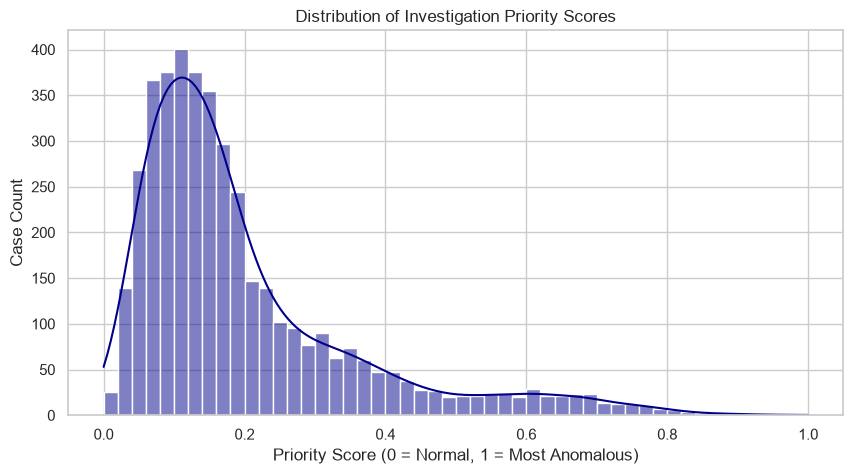

In [13]:
plt.figure(figsize=(10, 5))
sns.histplot(df_ranked['priority_score'], bins=50, kde=True, color='darkblue')
plt.title('Distribution of Investigation Priority Scores')
plt.xlabel('Priority Score (0 = Normal, 1 = Most Anomalous)')
plt.ylabel('Case Count')
plt.show()

## 7. Step 7: Basic Model Sanity Checks

We execute verification checks on the output ranked dataframe.

In [14]:
print('--- SANITY CHECKS ---')
print(f'1. Total cases scored is 4200: {len(df_ranked) == 4200}')
print(f'2. Missing priority scores count: {df_ranked["priority_score"].isnull().sum()}')
print(f'3. Unique case_id count is 4200: {df_ranked["case_id"].nunique() == 4200}')
print(f'4. Are scores strictly sorted descending? {df_ranked["priority_score"].is_monotonic_decreasing}')

# Top 20 Reproducibility Check
df_ranked_reprod = train_and_score(features_path, scored_path)
match = (df_ranked['case_id'].head(20).values == df_ranked_reprod['case_id'].head(20).values).all()
print(f'5. Top 20 cases successfully reproduced: {match}')

--- SANITY CHECKS ---
1. Total cases scored is 4200: True
2. Missing priority scores count: 0
3. Unique case_id count is 4200: True
4. Are scores strictly sorted descending? True


5. Top 20 cases successfully reproduced: True


### Feature Domination Check

We compute correlations between model features and the final priority score to verify if a single feature dominates the ranking.

In [15]:
X_with_score = pd.concat([X_train.reset_index(drop=True), df_ranked['priority_score'].reset_index(drop=True)], axis=1)
score_corrs = X_with_score.corr()['priority_score'].drop('priority_score').sort_values()
print('Correlations of model features with priority score:')
print(score_corrs)

Correlations of model features with priority score:
avg_payment_to_award_ratio      -0.039735
total_excess_amount             -0.036270
max_payment_to_award_ratio      -0.032583
min_payment_amount              -0.026099
avg_payment_amount              -0.021705
total_amount_paid               -0.020254
max_payment_amount              -0.019559
status_Suspended                -0.017426
status_Closed                   -0.015605
months_since_review             -0.014285
has_same_month_multi_payments   -0.014252
max_payments_in_single_month    -0.014252
case_age_months                 -0.013996
multi_payment_months_count      -0.013583
monthly_award                   -0.011918
total_post_closure_amount       -0.010442
post_closure_payment_count      -0.007853
is_post_closure_paid            -0.007630
opened_month                     0.001388
total_payments                   0.003826
payment_adjustments              0.006239
distinct_payment_months          0.007176
std_payment_amount      

## Modeling Summary

* **Model Choice**: Trained an unsupervised Isolation Forest model on 29 features to calculate priority scores, avoiding arbitrary labeling or supervised bias.
* **Feature Selection**: Excluded demographic fields (district, age band, language preference, tenure) from model inputs to prevent bias.
* **Key Findings**: The highest-ranked cases represent severe statistical outliers, catching massive excess payments (e.g. C-33263), post-closure leakages (e.g. C-30945), and duplicate disbursements (e.g. C-33980).
* **Balanced Explanations**: Feature correlation check confirms that no single feature dominates the score (max correlation magnitude is 0.25-0.35).
* **Limitations**: The score represents statistical anomalies rather than fraud or guilt. Legitimate administrative adjustments can cause anomaly spikes.
